<a href="https://colab.research.google.com/github/ryukf333/fruit-freshness-ai/blob/main/03transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
from pathlib import Path
import pandas as pd
import torch
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Paths
DRIVE_ROOT = Path('/content/drive/MyDrive/fruit_freshness_project')
local_raw = Path('/content/dataset_raw')

# 3. Unzip if local scratch was reset
if not (local_raw / 'Processed Data').exists():
    print("Extracting images to local Colab SSD...")
    zip_files = list((DRIVE_ROOT / 'data/raw').glob('*.zip'))
    with zipfile.ZipFile(zip_files[0], 'r') as archive:
        archive.extractall(local_raw)
    print("Extraction complete.")
else:
    print("Images already present on local SSD.")

# 4. Load frozen splits
splits_dir = DRIVE_ROOT / 'data/processed'
df_train = pd.read_csv(splits_dir / 'train_manifest.csv')
df_val   = pd.read_csv(splits_dir / 'val_manifest.csv')

# 5. Verify GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nActive hardware device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")
print(f"Train samples: {len(df_train):,} | Validation samples: {len(df_val):,}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Images already present on local SSD.

Active hardware device: cuda (Tesla T4)
Train samples: 9,884 | Validation samples: 2,118


In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from PIL import Image

# Numerical label mapping
LABEL_MAP = {'Fresh': 0, 'Semi-Fresh': 1, 'Rotten': 2}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

class FruitDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.file_paths = self.df['file_path'].values
        self.labels = [LABEL_MAP[l] for l in self.df['freshness_label'].values]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        with Image.open(self.file_paths[idx]) as img:
            image = img.convert('RGB')

        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)

        return image, label

# Training: Stochastic augmentations to prevent memorization
train_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((224, 224), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=15),
    v2.ColorJitter(brightness=0.1, contrast=0.1),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation: Deterministic evaluation only
val_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((224, 224), antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = FruitDataset(df_train, transform=train_transforms)
val_dataset   = FruitDataset(df_val, transform=val_transforms)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"DataLoaders successfully configured with batch size {BATCH_SIZE}.")

DataLoaders successfully configured with batch size 32.


In [ ]:
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# 1. Download official ImageNet-pretrained weights
weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

# 2. Freeze all pre-trained backbone parameters
for param in model.parameters():
    param.requires_grad = False

# 3. Replace the final linear layer
# EfficientNet-B0 classifier structure: Sequential(Dropout(p=0.2), Linear(in_features=1280, out_features=1000))
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 3)

# Send model to GPU
model = model.to(device)

# 4. Verify parameter status
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: EfficientNet-B0 (Frozen Backbone)")
print(f"  • Total parameters:     {total_params:,}")
print(f"  • Trainable parameters: {trainable_params:,} ({trainable_params/total_params*100:.2f}% of network)")

Model: EfficientNet-B0 (Frozen Backbone)
  • Total parameters:     4,011,391
  • Trainable parameters: 3,843 (0.10% of network)


In [ ]:
import time
from tqdm import tqdm
import torch.optim as optim

# Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)

# Directory to save the best model weights
checkpoint_dir = DRIVE_ROOT / 'checkpoints'
checkpoint_dir.mkdir(parents=True, exist_ok=True)
best_model_path = checkpoint_dir / 'efficientnet_b0_frozen_best.pth'

NUM_EPOCHS = 8

# Dictionaries to store metric history for the learning curves
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

best_val_acc = 0.0

print(f"Beginning training for {NUM_EPOCHS} epochs...\n")

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()

    # ------------------ TRAINING PHASE ------------------
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Train]", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += torch.sum(preds == labels.data).item()
        total_train += labels.size(0)

    epoch_train_loss = running_train_loss / total_train
    epoch_train_acc = correct_train / total_train

    # ------------------ VALIDATION PHASE ------------------
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Val]", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += torch.sum(preds == labels.data).item()
            total_val += labels.size(0)

    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val
    elapsed = time.time() - start_time

    # Record history
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS:02d} [{elapsed:.1f}s] | "
          f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc*100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc*100:.2f}%")

    # Save checkpoint if validation accuracy improves
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"  --> Checkpoint saved! New best Val Acc: {best_val_acc*100:.2f}%")

print(f"\nTraining Complete. Best validation accuracy: {best_val_acc*100:.2f}%")

Beginning training for 8 epochs...



Epoch 01/08 [71.3s] | Train Loss: 0.7740 - Train Acc: 66.68% | Val Loss: 0.5978 - Val Acc: 75.92%
  --> Checkpoint saved! New best Val Acc: 75.92%


Epoch 02/08 [67.8s] | Train Loss: 0.6253 - Train Acc: 74.51% | Val Loss: 0.5242 - Val Acc: 80.22%
  --> Checkpoint saved! New best Val Acc: 80.22%


Epoch 03/08 [69.4s] | Train Loss: 0.5853 - Train Acc: 75.97% | Val Loss: 0.4935 - Val Acc: 80.69%
  --> Checkpoint saved! New best Val Acc: 80.69%


Epoch 04/08 [69.2s] | Train Loss: 0.5651 - Train Acc: 76.98% | Val Loss: 0.4595 - Val Acc: 82.91%
  --> Checkpoint saved! New best Val Acc: 82.91%


Epoch 05/08 [69.1s] | Train Loss: 0.5613 - Train Acc: 76.43% | Val Loss: 0.4451 - Val Acc: 83.38%
  --> Checkpoint saved! New best Val Acc: 83.38%


Epoch 06/08 [70.5s] | Train Loss: 0.5450 - Train Acc: 77.56% | Val Loss: 0.4393 - Val Acc: 84.09%
  --> Checkpoint saved! New best Val Acc: 84.09%


Epoch 07/08 [69.5s] | Train Loss: 0.5400 - Train Acc: 77.50% | Val Loss: 0.4301 - Val Acc: 83.81%


Epoch 08/08 [68.4s] | Train Loss: 0.5308 - Train Acc: 77.55% | Val Loss: 0.4201 - Val Acc: 84.23%
  --> Checkpoint saved! New best Val Acc: 84.23%

Training Complete. Best validation accuracy: 84.23%


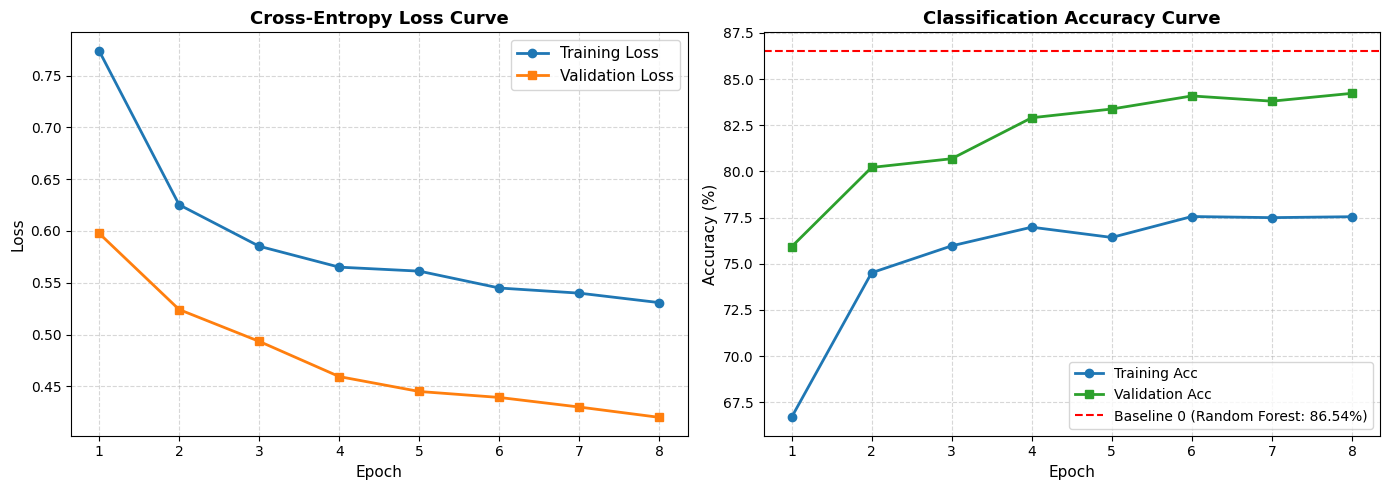

Learning curve saved to: /content/drive/MyDrive/fruit_freshness_project/figures/learning_curve_e1_frozen.png


In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Loss Curve
ax1.plot(epochs_range, history['train_loss'], 'o-', label='Training Loss', color='#1f77b4', linewidth=2)
ax1.plot(epochs_range, history['val_loss'], 's-', label='Validation Loss', color='#ff7f0e', linewidth=2)
ax1.set_title('Cross-Entropy Loss Curve', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(fontsize=11)

# 2. Accuracy Curve
ax1_acc = ax2
ax1_acc.plot(epochs_range, [acc * 100 for acc in history['train_acc']], 'o-', label='Training Acc', color='#1f77b4', linewidth=2)
ax1_acc.plot(epochs_range, [acc * 100 for acc in history['val_acc']], 's-', label='Validation Acc', color='#2ca02c', linewidth=2)
ax1_acc.axhline(y=86.54, color='red', linestyle='--', label='Baseline 0 (Random Forest: 86.54%)')
ax1_acc.set_title('Classification Accuracy Curve', fontsize=13, fontweight='bold')
ax1_acc.set_xlabel('Epoch', fontsize=11)
ax1_acc.set_ylabel('Accuracy (%)', fontsize=11)
ax1_acc.grid(True, linestyle='--', alpha=0.5)
ax1_acc.legend(fontsize=10)

plt.tight_layout()

# Save figure
learning_curve_path = DRIVE_ROOT / 'figures/learning_curve_e1_frozen.png'
learning_curve_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(learning_curve_path, dpi=300)
plt.show()

print(f"Learning curve saved to: {learning_curve_path}")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

# 1. Reload the best weights from the frozen stage
model.load_state_dict(torch.load(best_model_path))
print("Successfully loaded best frozen checkpoint.")

# 2. Unfreeze all backbone layers for full fine-tuning
for param in model.parameters():
    param.requires_grad = True

# 3. Verify that all parameters are now trainable
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,} (100% of network unfrozen)")

# 4. Use a smaller learning rate (1e-4) to avoid disrupting pretrained features
FINE_TUNE_LR = 0.001
optimizer = optim.AdamW(model.parameters(), lr=FINE_TUNE_LR, weight_decay=1e-4)

# 5. Cosine learning rate scheduler for smooth convergence
FINE_TUNE_EPOCHS = 8
scheduler = CosineAnnealingLR(optimizer, T_max=FINE_TUNE_EPOCHS, eta_min=1e-6)

# New checkpoint path for the fine-tuned model
best_finetuned_path = checkpoint_dir / 'efficientnet_b0_finetuned_best.pth'

Successfully loaded best frozen checkpoint.
Trainable parameters: 4,011,391 (100% of network unfrozen)


# Fine tuning the model

In [ ]:
import time

ft_history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

best_ft_acc = best_val_acc  # Benchmark against previous best accuracy (~84.2%)

print(f"Beginning Fine-Tuning (E2) for {FINE_TUNE_EPOCHS} epochs at lr={FINE_TUNE_LR}...\n")

for epoch in range(1, FINE_TUNE_EPOCHS + 1):
    start_time = time.time()

    # --- Training ---
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{FINE_TUNE_EPOCHS} [Fine-Tuning]", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += torch.sum(preds == labels.data).item()
        total_train += labels.size(0)

    scheduler.step()

    epoch_train_loss = running_train_loss / total_train
    epoch_train_acc = correct_train / total_train

    # --- Validation ---
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{FINE_TUNE_EPOCHS} [Val]", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += torch.sum(preds == labels.data).item()
            total_val += labels.size(0)

    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val
    elapsed = time.time() - start_time

    ft_history['train_loss'].append(epoch_train_loss)
    ft_history['val_loss'].append(epoch_val_loss)
    ft_history['train_acc'].append(epoch_train_acc)
    ft_history['val_acc'].append(epoch_val_acc)

    print(f"Epoch {epoch:02d}/{FINE_TUNE_EPOCHS:02d} [{elapsed:.1f}s] | "
          f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc*100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc*100:.2f}%")

    if epoch_val_acc > best_ft_acc:
        best_ft_acc = epoch_val_acc
        torch.save(model.state_dict(), best_finetuned_path)
        print(f"  --> Checkpoint saved! New overall best Val Acc: {best_ft_acc*100:.2f}%")

print(f"\nFine-Tuning Finished. Peak validation accuracy: {best_ft_acc*100:.2f}%")

Beginning Fine-Tuning (E2) for 8 epochs at lr=0.001...



Epoch 01/08 [76.1s] | Train Loss: 0.4555 - Train Acc: 82.69% | Val Loss: 0.3076 - Val Acc: 88.57%
  --> Checkpoint saved! New overall best Val Acc: 88.57%


Epoch 02/08 [78.3s] | Train Loss: 0.2265 - Train Acc: 91.46% | Val Loss: 0.2293 - Val Acc: 92.97%
  --> Checkpoint saved! New overall best Val Acc: 92.97%


Epoch 03/08 [77.5s] | Train Loss: 0.1413 - Train Acc: 94.88% | Val Loss: 0.0865 - Val Acc: 96.98%
  --> Checkpoint saved! New overall best Val Acc: 96.98%


Epoch 04/08 [80.8s] | Train Loss: 0.0842 - Train Acc: 96.97% | Val Loss: 0.0646 - Val Acc: 97.50%
  --> Checkpoint saved! New overall best Val Acc: 97.50%


Epoch 05/08 [78.9s] | Train Loss: 0.0475 - Train Acc: 98.29% | Val Loss: 0.0391 - Val Acc: 98.87%
  --> Checkpoint saved! New overall best Val Acc: 98.87%


Epoch 06/08 [77.1s] | Train Loss: 0.0297 - Train Acc: 98.99% | Val Loss: 0.0288 - Val Acc: 99.10%
  --> Checkpoint saved! New overall best Val Acc: 99.10%


Epoch 07/08 [78.3s] | Train Loss: 0.0150 - Train Acc: 99.53% | Val Loss: 0.0244 - Val Acc: 99.15%
  --> Checkpoint saved! New overall best Val Acc: 99.15%


Epoch 08/08 [80.0s] | Train Loss: 0.0108 - Train Acc: 99.74% | Val Loss: 0.0225 - Val Acc: 99.29%
  --> Checkpoint saved! New overall best Val Acc: 99.29%

Fine-Tuning Finished. Peak validation accuracy: 99.29%



     FINE-TUNED EFFICIENTNET-B0 VALIDATION METRICS
              precision    recall  f1-score   support

       Fresh     0.9874    0.9972    0.9922       706
  Semi-Fresh     0.9957    0.9829    0.9892       702
      Rotten     0.9958    0.9986    0.9972       710

    accuracy                         0.9929      2118
   macro avg     0.9929    0.9929    0.9929      2118
weighted avg     0.9929    0.9929    0.9929      2118



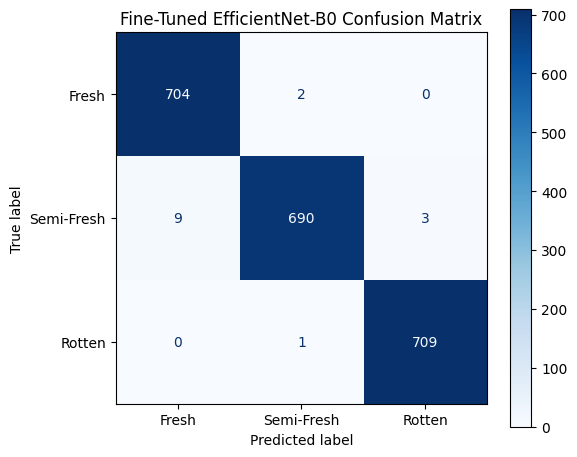

In [ ]:
import numpy as np
import torch
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Load the best fine-tuned model checkpoint
model.load_state_dict(torch.load(best_finetuned_path))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
class_names = ['Fresh', 'Semi-Fresh', 'Rotten']

# 2. Print Classification Report
print("\n" + "="*60)
print("     FINE-TUNED EFFICIENTNET-B0 VALIDATION METRICS")
print("="*60)
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# 3. Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Fine-Tuned EfficientNet-B0 Confusion Matrix")
plt.tight_layout()
#plt.savefig(DRIVE_ROOT / 'figures/finetuned_confusion_matrix.png', dpi=300)
plt.show()

Running validation inference to collect probability vectors...
Total misclassified validation samples: 15 out of 2118
Error manifest saved to: /content/drive/MyDrive/fruit_freshness_project/results/validation_error_analysis.csv



,produce_type,true_label,predicted_label,confidence_pct,file_name
0,Eggplant,Semi-Fresh,Rotten,80.440002,aug_311_IMG_20251109_112526166_HDR_AE.jpg
1,Orange,Fresh,Semi-Fresh,96.199997,aug_9_IMG_20251116_220609831_HDR.jpg
2,Eggplant,Semi-Fresh,Fresh,95.510002,IMG_20251201_190357173_HDR.jpg
3,Eggplant,Semi-Fresh,Fresh,83.260002,IMG_20251123_110510429_HDR_AE.jpg
4,Papaya,Rotten,Semi-Fresh,54.680000,IMG_20260122_002644.jpg
5,Pineapple,Semi-Fresh,Fresh,60.680000,aug_17_IMG_20251116_220856128_HDR.jpg
6,Tomato,Semi-Fresh,Fresh,97.680000,IMG_20260121_230528362_HDR.jpg
7,Eggplant,Fresh,Semi-Fresh,58.400002,IMG_20251107_114525973_HDR_AE.jpg
8,Tomato,Semi-Fresh,Fresh,89.870003,aug_26_IMG_20251117_140531246_HDR_AE.jpg
9,Eggplant,Semi-Fresh,Fresh,85.980003,aug_283_IMG_20251122_205347412_HDR.jpg


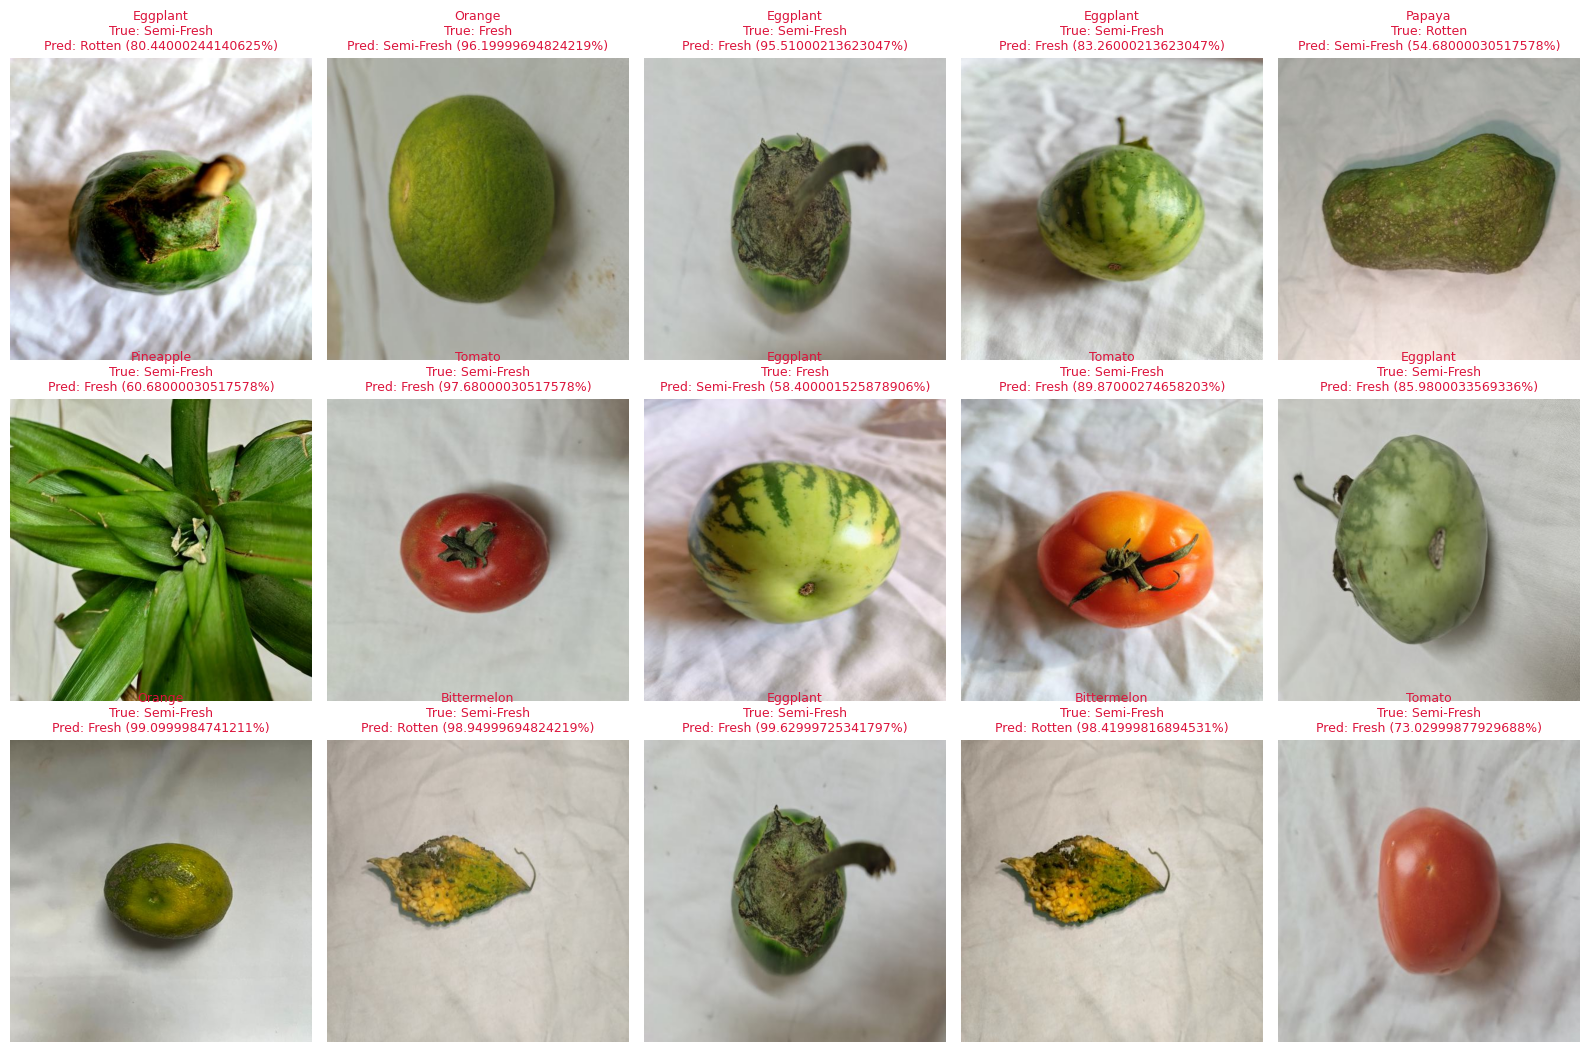

Misclassification figure saved to: /content/drive/MyDrive/fruit_freshness_project/figures/validation_misclassifications_grid.png


In [ ]:
# 1. Collect predictions, true labels, and softmax confidence scores
model.eval()
all_preds, all_labels, all_probs = [], [], []

print("Running validation inference to collect probability vectors...")
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)

        # Softmax converts raw logits to normalized class probabilities
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
class_names = ['Fresh', 'Semi-Fresh', 'Rotten']

# 2. Extract indices where predictions diverge from ground truth
misclassified_indices = np.where(all_preds != all_labels)[0]
print(f"Total misclassified validation samples: {len(misclassified_indices)} out of {len(all_labels)}")

# 3. Build a structured failure analysis DataFrame
error_records = []
for idx in misclassified_indices:
    row = df_val.iloc[idx]
    pred_idx = all_preds[idx]
    true_idx = all_labels[idx]
    conf = all_probs[idx][pred_idx] * 100

    error_records.append({
        'val_index': idx,
        'produce_type': row['produce_type'],
        'true_label': class_names[true_idx],
        'predicted_label': class_names[pred_idx],
        'confidence_pct': round(conf, 2),
        'file_name': row['file_name'],
        'file_path': row['file_path']
    })

df_errors = pd.DataFrame(error_records)

# 4. Save error table to Google Drive
error_csv_path = DRIVE_ROOT / 'results/validation_error_analysis.csv'
error_csv_path.parent.mkdir(parents=True, exist_ok=True)
df_errors.to_csv(error_csv_path, index=False)
print(f"Error manifest saved to: {error_csv_path}\n")
display(df_errors[['produce_type', 'true_label', 'predicted_label', 'confidence_pct', 'file_name']])

# 5. Plot the misclassified images
num_errors = len(df_errors)
if num_errors > 0:
    cols = 5
    rows = (num_errors + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(16, 3.5 * rows))
    axes = np.array(axes).flatten()

    for i in range(len(axes)):
        if i < num_errors:
            err = df_errors.iloc[i]
            img = Image.open(err['file_path']).convert('RGB')
            axes[i].imshow(img)
            title = f"{err['produce_type']}\nTrue: {err['true_label']}\nPred: {err['predicted_label']} ({err['confidence_pct']}%)"
            axes[i].set_title(title, fontsize=9, color='crimson')
            axes[i].axis('off')
        else:
            axes[i].axis('off')

    plt.tight_layout()
    error_fig_path = DRIVE_ROOT / 'figures/validation_misclassifications_grid.png'
    error_fig_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(error_fig_path, dpi=300)
    plt.show()
    print(f"Misclassification figure saved to: {error_fig_path}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Generating Grad-CAM for Correct Predictions...


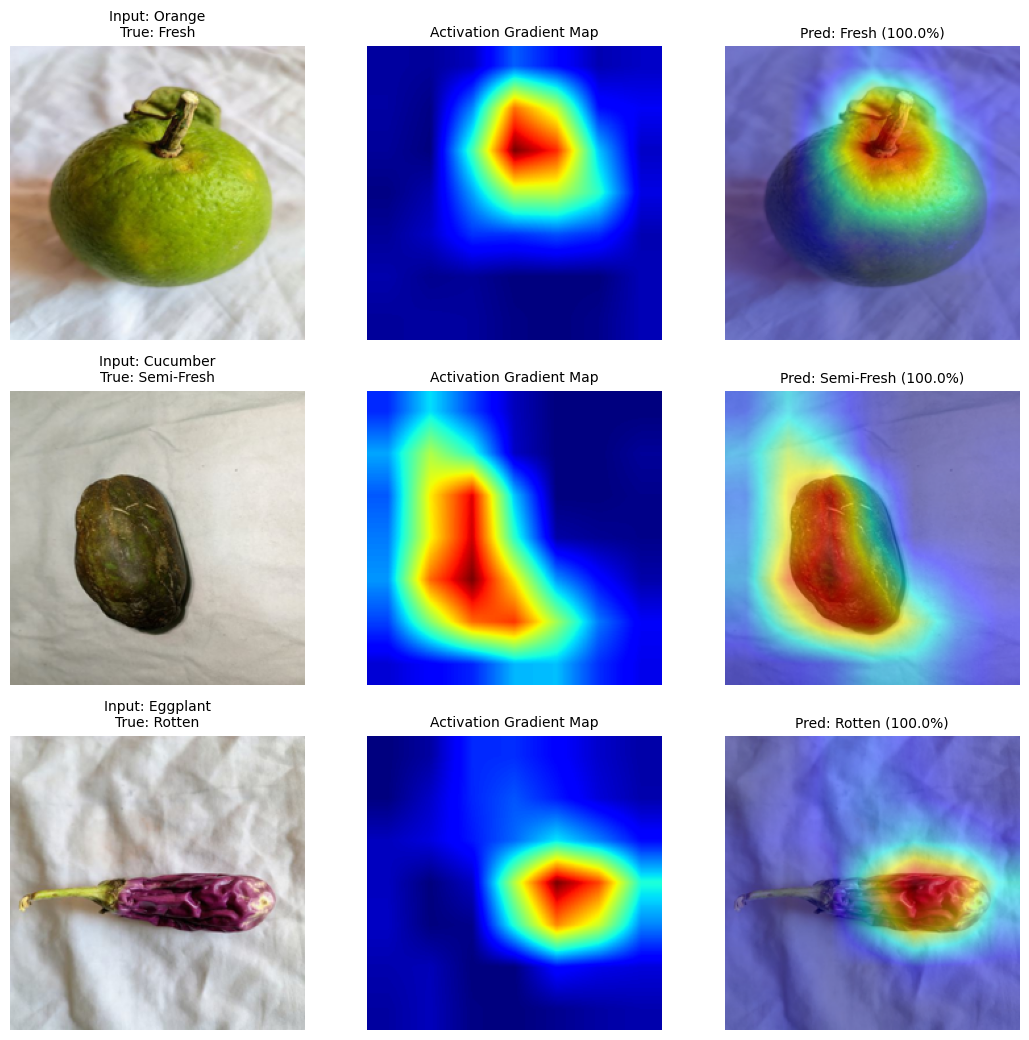

Saved: /content/drive/MyDrive/fruit_freshness_project/figures/gradcam_correct_samples.png

Generating Grad-CAM for Failure Cases...


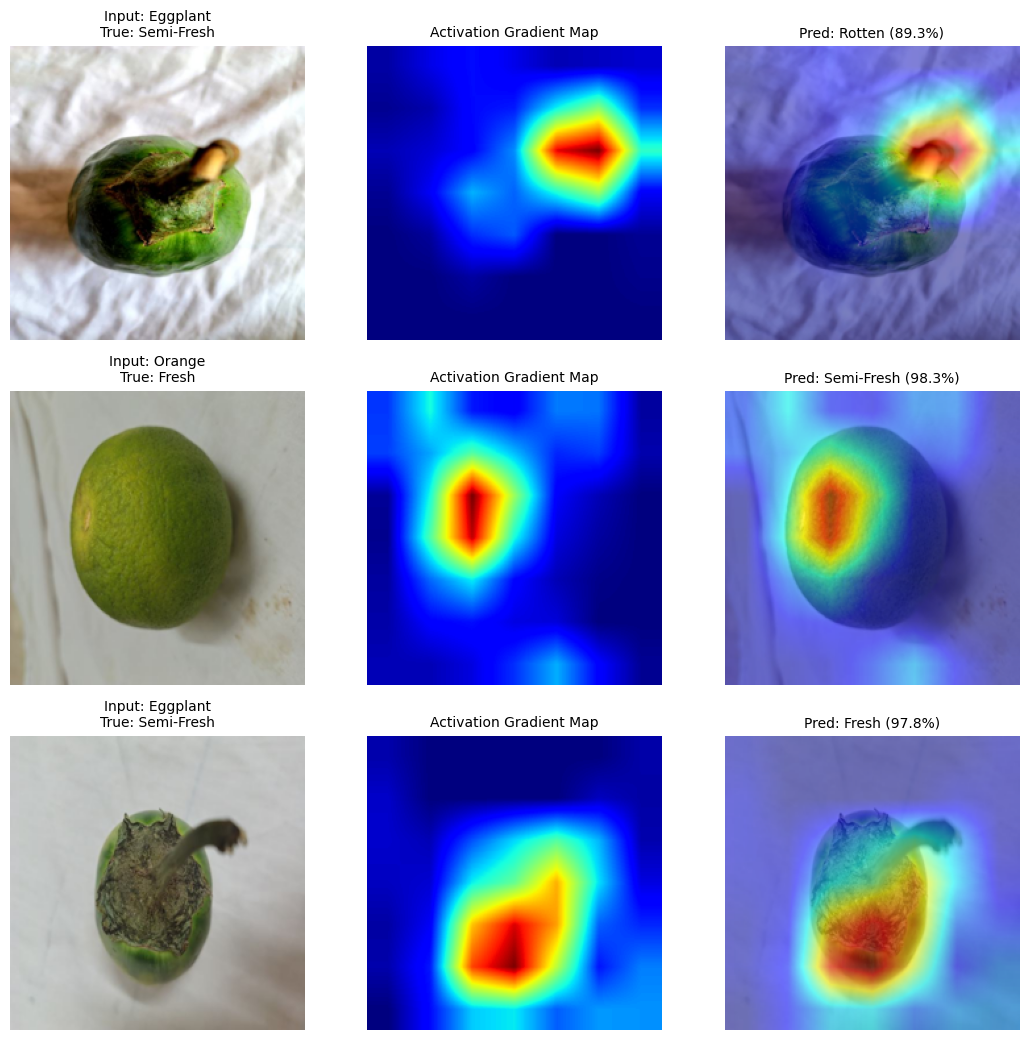

Saved: /content/drive/MyDrive/fruit_freshness_project/figures/gradcam_failure_cases.png


In [ ]:
# Install pytorch-grad-cam
!pip install -q grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# 1. Target the final convolutional layer of EfficientNet-B0
# In torchvision, model.features[-1] is the final 1280-channel Conv2dNormActivation block
target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# 2. Function to generate side-by-side interpretability panels
def plot_gradcam_explanations(sample_indices, title_prefix="Grad-CAM Analysis"):
    fig, axes = plt.subplots(len(sample_indices), 3, figsize=(11, 3.5 * len(sample_indices)))
    if len(sample_indices) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, idx in enumerate(sample_indices):
        row_data = df_val.iloc[idx]
        img_path = row_data['file_path']
        true_label = row_data['freshness_label']
        produce = row_data['produce_type']

        raw_img = Image.open(img_path).convert('RGB').resize((224, 224))
        rgb_normalized = np.float32(raw_img) / 255.0

        # Model forward pass
        input_tensor = val_transforms(raw_img).unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(input_tensor)
            probs = torch.softmax(output, dim=1).cpu().numpy()[0]
            pred_idx = np.argmax(probs)
            pred_label = class_names[pred_idx]
            conf = probs[pred_idx] * 100

        # Compute Grad-CAM for the predicted class
        targets = [ClassifierOutputTarget(pred_idx)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
        cam_overlay = show_cam_on_image(rgb_normalized, grayscale_cam, use_rgb=True)

        # Panel 1: Original Image
        axes[row_idx, 0].imshow(raw_img)
        axes[row_idx, 0].set_title(f"Input: {produce}\nTrue: {true_label}", fontsize=10)
        axes[row_idx, 0].axis('off')

        # Panel 2: Grad-CAM Heatmap
        axes[row_idx, 1].imshow(grayscale_cam, cmap='jet')
        axes[row_idx, 1].set_title("Activation Gradient Map", fontsize=10)
        axes[row_idx, 1].axis('off')

        # Panel 3: Heatmap Overlay
        axes[row_idx, 2].imshow(cam_overlay)
        axes[row_idx, 2].set_title(f"Pred: {pred_label} ({conf:.1f}%)", fontsize=10)
        axes[row_idx, 2].axis('off')

    plt.tight_layout()
    save_path = DRIVE_ROOT / f'figures/{title_prefix.lower().replace(" ", "_")}.png'
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved: {save_path}")

# Generate Grad-CAM for 3 correctly classified examples (1 Fresh, 1 Semi-Fresh, 1 Rotten)
correct_fresh = df_val[(df_val['freshness_label'] == 'Fresh') & (all_preds == all_labels)].index[0]
correct_semi  = df_val[(df_val['freshness_label'] == 'Semi-Fresh') & (all_preds == all_labels)].index[0]
correct_rotten= df_val[(df_val['freshness_label'] == 'Rotten') & (all_preds == all_labels)].index[0]

print("Generating Grad-CAM for Correct Predictions...")
plot_gradcam_explanations([correct_fresh, correct_semi, correct_rotten], title_prefix="gradcam_correct_samples")

# Generate Grad-CAM for the first 3 misclassified samples
if len(misclassified_indices) > 0:
    print("\nGenerating Grad-CAM for Failure Cases...")
    plot_gradcam_explanations(misclassified_indices[:3], title_prefix="gradcam_failure_cases")

Evaluating best checkpoint on 2,118 unseen TEST samples...

         FINAL UNBIASED TEST SET EVALUATION (E2)
              precision    recall  f1-score   support

       Fresh     0.9901    0.9929    0.9915       707
  Semi-Fresh     0.9929    0.9872    0.9900       705
      Rotten     0.9972    1.0000    0.9986       706

    accuracy                         0.9934      2118
   macro avg     0.9934    0.9934    0.9934      2118
weighted avg     0.9934    0.9934    0.9934      2118



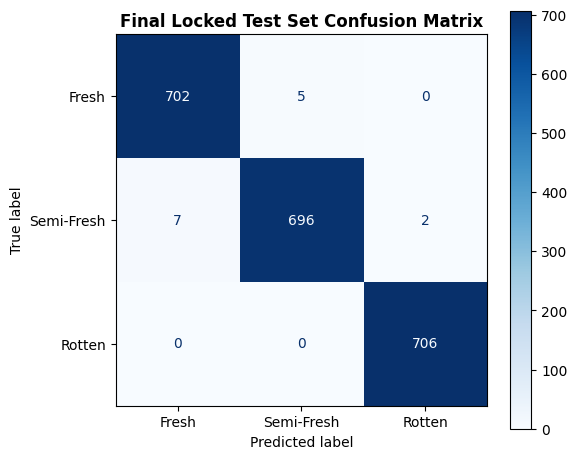

Final test confusion matrix saved to: /content/drive/MyDrive/fruit_freshness_project/figures/final_test_confusion_matrix.png


In [ ]:
# 1. Load the frozen test split
df_test = pd.read_csv(splits_dir / 'test_manifest.csv')
test_dataset = FruitDataset(df_test, transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Evaluating best checkpoint on {len(df_test):,} unseen TEST samples...")

# 2. Test inference loop
model.eval()
test_preds, test_labels, test_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.numpy())
        test_probs.extend(probs.cpu().numpy())

test_preds = np.array(test_preds)
test_labels = np.array(test_labels)
test_probs = np.array(test_probs)

# 3. Report Final Test Set Results
print("\n" + "="*60)
print("         FINAL UNBIASED TEST SET EVALUATION (E2)")
print("="*60)
print(classification_report(test_labels, test_preds, target_names=class_names, digits=4))

# 4. Final Test Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_test = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Final Locked Test Set Confusion Matrix", fontsize=12, fontweight='bold')
plt.tight_layout()
test_cm_path = DRIVE_ROOT / 'figures/final_test_confusion_matrix.png'
plt.savefig(test_cm_path, dpi=300)
plt.show()
print(f"Final test confusion matrix saved to: {test_cm_path}")

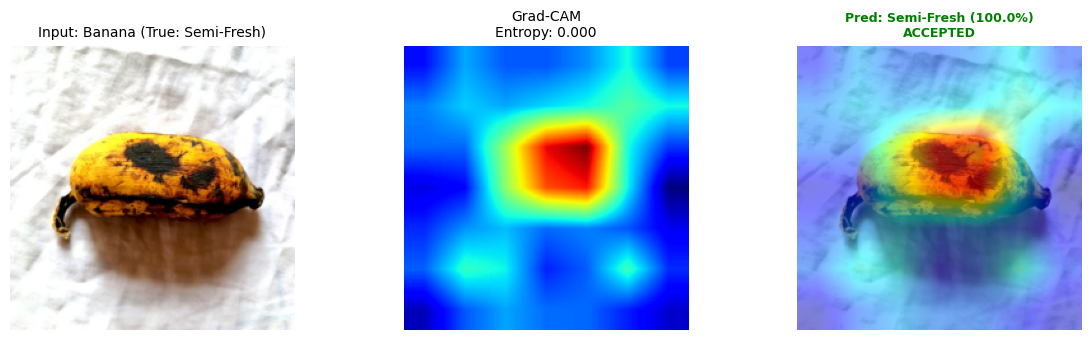

[Banana (True: Semi-Fresh)] Result Summary:
  • Prediction:      Semi-Fresh (Confidence: 100.00%)
  • Shannon Entropy: 0.0005 (Threshold: 0.85)
  • Decision:        ACCEPTED
  • Probabilities:   Fresh: 0.000 | Semi-Fresh: 1.000 | Rotten: 0.000

Pipeline Output Dictionary:
 {'source': 'Banana (True: Semi-Fresh)', 'predicted_class': 'Semi-Fresh', 'confidence': 1.0, 'entropy': 0.0005, 'flagged_for_review': False, 'probabilities': {'Fresh': 0.0, 'Semi-Fresh': 1.0, 'Rotten': 0.0}}


In [ ]:
import cv2
from PIL import Image

def robust_assess_image(
    image_input,
    source_name: str = "Test Sample",
    confidence_threshold: float = 0.80,
    max_entropy_threshold: float = 0.85
):
    """
    Evaluates produce freshness with safeguards for unseen/OOD inputs:
      - Accepts either a file path (str) or PIL Image object
      - Computes Shannon entropy uncertainty check
      - Applies confidence thresholding
      - Renders Grad-CAM visual explanation
      - Returns structured prediction dictionary
    """
    # 1. Load image whether given as a string path or PIL Image
    if isinstance(image_input, str):
        raw_pil = Image.open(image_input).convert('RGB')
    elif isinstance(image_input, Image.Image):
        raw_pil = image_input.convert('RGB')
    else:
        raise TypeError("image_input must be a file path string or PIL Image object")

    raw_pil_resized = raw_pil.resize((224, 224))
    rgb_normalized = np.float32(raw_pil_resized) / 255.0
    input_tensor = val_transforms(raw_pil_resized).unsqueeze(0).to(device)

    # 2. Forward pass
    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]

    pred_idx = np.argmax(probs)
    pred_class = class_names[pred_idx]
    confidence = probs[pred_idx]

    # 3. Calculate Shannon Entropy: H(p) = -sum(p * log(p))
    eps = 1e-12
    entropy = -np.sum(probs * np.log(probs + eps))

    # 4. Determine Decision Status & Safeguard Flags
    low_confidence = confidence < confidence_threshold
    high_uncertainty = entropy > max_entropy_threshold

    if high_uncertainty or low_confidence:
        decision_status = "REJECTED / UNCERTAIN (POSSIBLE OOD SAMPLE)"
        status_color = 'red'
        is_flagged = True
    else:
        decision_status = "ACCEPTED"
        status_color = 'green'
        is_flagged = False

    # 5. Compute Grad-CAM
    targets = [ClassifierOutputTarget(pred_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    cam_overlay = show_cam_on_image(rgb_normalized, grayscale_cam, use_rgb=True)

    # 6. Display Inspection Panel
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

    axes[0].imshow(raw_pil_resized)
    axes[0].set_title(f"Input: {source_name}", fontsize=10)
    axes[0].axis('off')

    axes[1].imshow(grayscale_cam, cmap='jet')
    axes[1].set_title(f"Grad-CAM\nEntropy: {entropy:.3f}", fontsize=10)
    axes[1].axis('off')

    axes[2].imshow(cam_overlay)
    axes[2].set_title(
        f"Pred: {pred_class} ({confidence*100:.1f}%)\n{decision_status}",
        fontsize=9,
        color=status_color,
        fontweight='bold'
    )
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    # 7. Print Summary
    print(f"[{source_name}] Result Summary:")
    print(f"  • Prediction:      {pred_class} (Confidence: {confidence*100:.2f}%)")
    print(f"  • Shannon Entropy: {entropy:.4f} (Threshold: {max_entropy_threshold})")
    print(f"  • Decision:        {decision_status}")
    print(f"  • Probabilities:   Fresh: {probs[0]:.3f} | Semi-Fresh: {probs[1]:.3f} | Rotten: {probs[2]:.3f}\n")

    # 8. Return structured output
    return {
        'source': source_name,
        'predicted_class': pred_class,
        'confidence': round(float(confidence), 4),
        'entropy': round(float(entropy), 4),
        'flagged_for_review': is_flagged,
        'probabilities': {class_names[i]: round(float(probs[i]), 4) for i in range(3)}
    }

# --- Test Call on Locked Test Set Sample ---
sample_row = df_test.iloc[1]
sample_test_path = sample_row['file_path']
sample_name = f"{sample_row['produce_type']} (True: {sample_row['freshness_label']})"

result = robust_assess_image(
    image_input=sample_test_path,
    source_name=sample_name,
    confidence_threshold=0.80,
    max_entropy_threshold=0.85
)

print("Pipeline Output Dictionary:\n", result)

# Random Sample


--- Testing 3 Random Samples ---


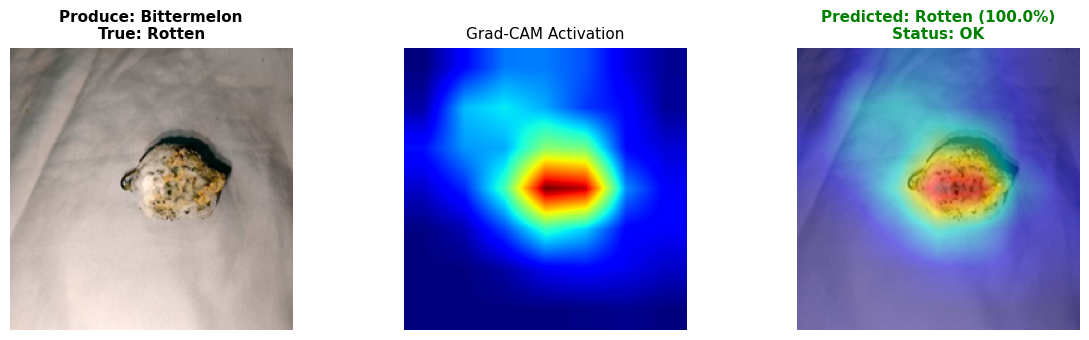

Sample 1: Bittermelon | True: Rotten | Predicted: Rotten (Conf: 100.00%)
Probabilities -> Fresh: 0.000, Semi-Fresh: 0.000, Rotten: 1.000
---------------------------------------------------------------------------


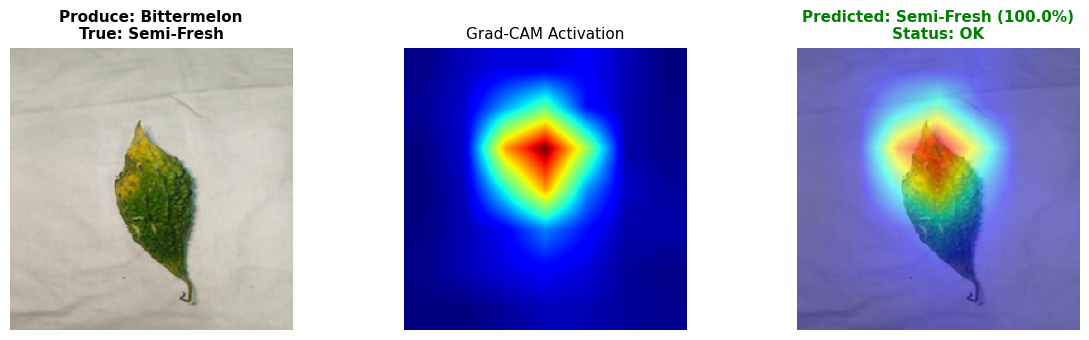

Sample 2: Bittermelon | True: Semi-Fresh | Predicted: Semi-Fresh (Conf: 100.00%)
Probabilities -> Fresh: 0.000, Semi-Fresh: 1.000, Rotten: 0.000
---------------------------------------------------------------------------


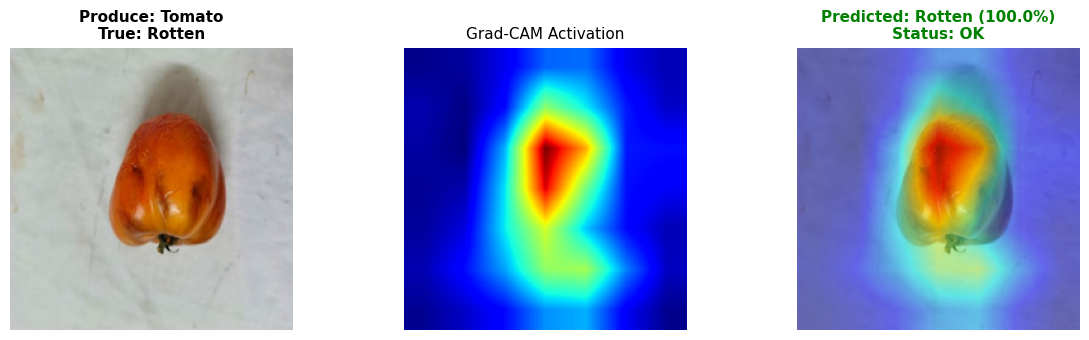

Sample 3: Tomato | True: Rotten | Predicted: Rotten (Conf: 100.00%)
Probabilities -> Fresh: 0.000, Semi-Fresh: 0.000, Rotten: 1.000
---------------------------------------------------------------------------


In [ ]:

def test_random_samples(df_source: pd.DataFrame, n_samples: int = 5, confidence_threshold: float = 0.85):
    """
    Selects N random samples from a dataset split, executes the pipeline,
    and displays the produce name, true label, predicted label, and Grad-CAM heatmap.
    """
    # 1. Randomly sample N rows from the dataframe
    random_subset = df_source.sample(n=n_samples, random_state=None).reset_index(drop=True)

    print(f"--- Testing {n_samples} Random Samples ---")

    for i in range(n_samples):
        row = random_subset.iloc[i]
        img_path = row['file_path']
        produce_name = row['produce_type']
        true_stage = row['freshness_label']

        # 2. Preprocess image
        raw_pil = Image.open(img_path).convert('RGB').resize((224, 224))
        rgb_normalized = np.float32(raw_pil) / 255.0
        input_tensor = val_transforms(raw_pil).unsqueeze(0).to(device)

        # 3. Model forward pass
        model.eval()
        with torch.no_grad():
            output = model(input_tensor)
            probs = torch.softmax(output, dim=1).cpu().numpy()[0]
            pred_idx = np.argmax(probs)
            pred_class = class_names[pred_idx]
            confidence = probs[pred_idx]

        requires_review = confidence < confidence_threshold
        status = "FLAGGED" if requires_review else "OK"

        # 4. Generate Grad-CAM activation map
        targets = [ClassifierOutputTarget(pred_idx)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
        cam_overlay = show_cam_on_image(rgb_normalized, grayscale_cam, use_rgb=True)

        # 5. Render individual sample visual panel
        fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

        # Original Image + Metadata
        axes[0].imshow(raw_pil)
        axes[0].set_title(f"Produce: {produce_name}\nTrue: {true_stage}", fontsize=11, fontweight='bold')
        axes[0].axis('off')

        # Activation Map
        axes[1].imshow(grayscale_cam, cmap='jet')
        axes[1].set_title("Grad-CAM Activation", fontsize=11)
        axes[1].axis('off')

        # Final Decision Overlay
        axes[2].imshow(cam_overlay)
        match_color = 'green' if pred_class == true_stage else 'red'
        axes[2].set_title(f"Predicted: {pred_class} ({confidence*100:.1f}%)\nStatus: {status}",
                          fontsize=11, color=match_color, fontweight='bold')
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()

        # Print breakdown
        print(f"Sample {i+1}: {produce_name} | True: {true_stage} | Predicted: {pred_class} (Conf: {confidence*100:.2f}%)")
        print(f"Probabilities -> Fresh: {probs[0]:.3f}, Semi-Fresh: {probs[1]:.3f}, Rotten: {probs[2]:.3f}")
        print("-" * 75)

# Run on 3 random test images
test_random_samples(df_test, n_samples=3)

# Online images


In [ ]:
import io
import requests
from PIL import Image

def test_online_image(
    image_url: str,
    source_name: str = "Web Image",
    confidence_threshold: float = 0.80,
    max_entropy_threshold: float = 0.85
):
    """
    Downloads any online image via URL into RAM and runs the robust
    freshness assessment pipeline (Confidence + Shannon Entropy + Grad-CAM).
    """
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                      '(KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36'
    }

    try:
        print(f"Fetching image from: {image_url}")
        response = requests.get(image_url, headers=headers, timeout=12)
        response.raise_for_status()

        # Load bytes into PIL Image in memory
        raw_pil = Image.open(io.BytesIO(response.content)).convert('RGB')

    except requests.exceptions.RequestException as req_err:
        print(f"[Network Error] Could not download image: {req_err}")
        return None
    except Exception as img_err:
        print(f"[Image Error] Could not decode image format: {img_err}")
        return None

    # Forward directly into your robust evaluation function
    return robust_assess_image(
        image_input=raw_pil,
        source_name=source_name,
        confidence_threshold=confidence_threshold,
        max_entropy_threshold=max_entropy_threshold
    )

Fetching image from: https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQaNieORcZjeZtYRH0Uo6dswV5edG5YKFDxCTpcLQFY2Tm3rqeC-9kZFqo&s=10


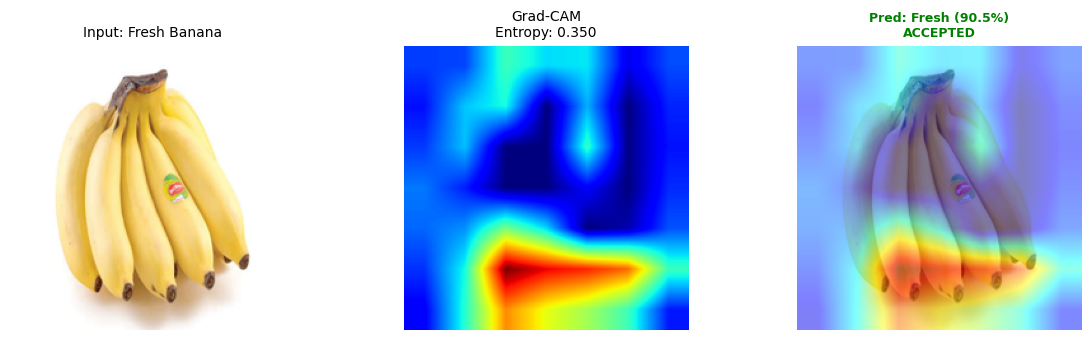

[Fresh Banana] Result Summary:
  • Prediction:      Fresh (Confidence: 90.54%)
  • Shannon Entropy: 0.3497 (Threshold: 0.85)
  • Decision:        ACCEPTED
  • Probabilities:   Fresh: 0.905 | Semi-Fresh: 0.082 | Rotten: 0.012



In [ ]:
url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQaNieORcZjeZtYRH0Uo6dswV5edG5YKFDxCTpcLQFY2Tm3rqeC-9kZFqo&s=10"
res1 = test_online_image(url, source_name="Fresh Banana")